In [1]:
from experiment.toolkits.plotting_helper import *
from experiment.toolkits.experiment_data_organizer import SpinStatistics
from experiment.toolkits.experiment_data_organizer.gradient_parameter_estimation import GradientParameterEstimation

import numpy as np
import matplotlib.pyplot as plt

/home/tqtraaqs/miniconda3/envs/tqtraaqs/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


0.5659827351021978
[0.56312004]


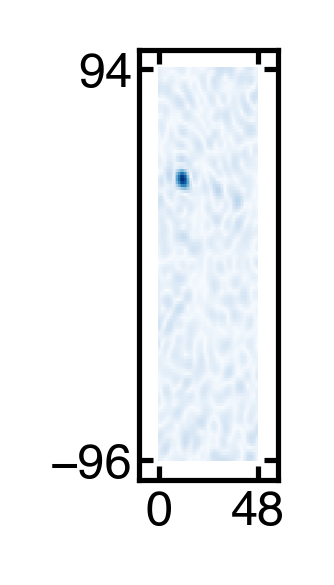

In [73]:
Ny, Nx = 29, 23
dy, dx = 5.22e-6, 10.49e-6

Nys, Nxs = 128, 128

eta = 0.55
fx = 11598
fy = 40774
phi = 0.5

X, Y = np.meshgrid(np.arange(Nx)*dx, np.arange(Ny)*dy, indexing = "xy")
x0, y0 = (Nx-1) * dx / 2, (Ny-1) * dy / 2
X -= x0
Y -= y0

p = 1 / 2 * (1 + np.cos(2 * np.pi * (fx * X + fy * Y) + phi))

np.random.seed(2323)
a0 = (np.random.rand(Ny, Nx) < eta).astype(int)
a1 = a0 * (np.random.rand(Ny, Nx) < p).astype(int)

m_s = np.where(a0 == 0, 0, 2 * a1 - 1)
m_s_dcr = m_s - np.mean(m_s)

m_s_fft = np.fft.fftshift( np.fft.rfft2(m_s_dcr, s = (Nys, Nxs), norm = "ortho"), axes = (0) )
v_fx = np.fft.rfftfreq(Nxs, d = dx)
v_fy = np.fft.fftshift( np.fft.fftfreq(Nys, d = dy) )
m_fx, m_fy = np.meshgrid(v_fx, v_fy, indexing = "xy")
m_s_fft = m_s_fft * np.exp(1j * 2 * np.pi * (m_fx * x0 + m_fy * y0))

iy, ix = np.unravel_index(np.argmax(np.abs(m_s_fft)), m_s_fft.shape)
fx0, fy0 = v_fx[ix], v_fy[iy]
peak = m_s_fft[iy, ix]

v_fx_min, v_fy_min, v_peak = GradientParameterEstimation.find_peak_with_dtft(m_s_dcr, fx0, fy0, dx, dy, origin=(y0, x0))

print(np.angle(peak))
print(np.angle(v_peak))

a0.astype(np.uint8).tofile("a0.bin")
a1.astype(np.uint8).tofile("a1.bin")

fig, ax = getStylishFigureAxes(1, 1, dpi=500)
extent = list(np.array([v_fx[0], v_fx[-1], v_fy[0], v_fy[-1]]) / 1e3)
ImagePlotter(fig, ax, np.abs(m_s_fft), False, pixel_extent = extent).draw()
ax.set_xticks([round(extent[0]), round(extent[1])])
ax.set_yticks([round(extent[2]), round(extent[3])])
automateAxisLimitsByTicks(ax, 0.2, 0.05)
plt.show()

In [67]:
np.random.seed(2323)

phi_list = []
v_phi_list = []

dy, dx = 1.0, 1.0
Ny, Nx = 29, 23
Nys, Nxs = 128, 128
m_s = np.zeros((Ny, Nx), dtype=float)
C = 1
for i in range(C):
    eta = 1.0
    fx = 3.2 / (Nx * dx)
    fy = 10.2 / (Ny * dy)
    phi = 0.1

    X, Y = np.meshgrid(np.arange(Nx)*dx, np.arange(Ny)*dy, indexing = "xy")
    x0, y0 = (Nx-1) * dx / 2, (Ny-1) * dy / 2
    X -= x0
    Y -= y0

    p = 1 / 2 * (1 + np.cos(2 * np.pi * (fx * X + fy * Y) + phi))

    a0 = (np.random.rand(Ny, Nx) < eta).astype(int)
    a1 = a0 * (np.random.rand(Ny, Nx) < p).astype(int)

    # m_s += np.where(a0 == 0, 0, 2 * a1 - 1) / C
    m_s += p / C

m_s_dcr = m_s - np.mean(m_s)

m_s_fft = np.fft.fftshift( np.fft.rfft2(m_s_dcr, s = (Nys, Nxs), norm = "ortho"), axes = (0) )
v_fx = np.fft.rfftfreq(Nxs, d = dx)
v_fy = np.fft.fftshift( np.fft.fftfreq(Nys, d = dy) )
m_fx, m_fy = np.meshgrid(v_fx, v_fy, indexing = "xy")
m_s_fft = m_s_fft * np.exp(1j * 2 * np.pi * (m_fx * x0 + m_fy * y0))

iy, ix = np.unravel_index(np.argmax(np.abs(m_s_fft)), m_s_fft.shape)
fx0, fy0 = v_fx[ix], v_fy[iy]
peak = m_s_fft[iy, ix]

v_fx_min, v_fy_min, v_peak = GradientParameterEstimation.find_peak_with_dtft(m_s_dcr, fx0, fy0, dx, dy, origin=(y0, x0))

v_phi_list.append(np.angle(v_peak))
phi_list.append(np.angle(peak))

v_phi_list = np.array(v_phi_list)
phi_list = np.array(phi_list)

print(phi_list.mean(), phi)
print(v_phi_list.mean(), phi)

0.09955422229813177 0.1
0.09956332028223795 0.1


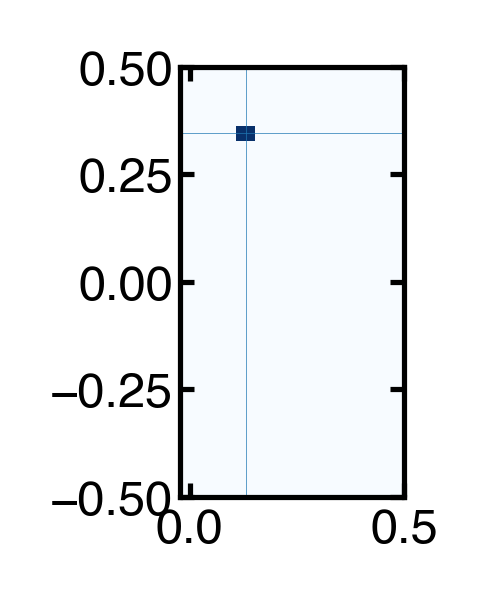

In [54]:
fig, ax=  getStylishFigureAxes(1, 1, dpi=500)
extent = list(np.array([v_fx[0], v_fx[-1], v_fy[0], v_fy[-1]]))
ImagePlotter(fig, ax, np.abs(m_s_fft), False, pixel_extent = extent).draw()
# plt.axvline(v_fx_min, linewidth = 0.1)
# plt.axhline(v_fy_min, linewidth = 0.1)
plt.axvline(fx, linewidth = 0.1)
plt.axhline(fy, linewidth = 0.1)
plt.show()